In [11]:
import os
import uuid
import time
import cv2

In [12]:
IMAGE_PATH = os.path.join('data', 'images')
number_images = 30

In [ ]:
cap = cv2.VideoCapture(0)
for imgnum in range(number_images):
    print('Collecting image {}'.format(imgnum))
    ret, frame = cap.read()
    imgname = os.path.join(IMAGE_PATH,f'{str(uuid.uuid1())}.jpg')
    cv2.imwrite(imgname, frame)
    cv2.imshow('frame', frame)
    time.sleep(0.5)

    if (cv2.waitKey(1) & 0xFF == ord('q')):
        break
cap.release()
cv2.destroyAllWindows()

Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.
Failed to capture image.


In [89]:
!labelme

2026-03-15 18:59:02.999 | INFO     | labelme.__main__:main:192 - Starting Labelme 5.11.4
2026-03-15 18:59:32.437 | DEBUG    | labelme.app:_scan_image_files:2351 - found 16 images in 'C:/Users/xx/Desktop/FaceDetectionML/data/test/images'
2026-03-15 18:59:32.439 | DEBUG    | labelme.app:_open_next_image:1980 - setting current row to 0
2026-03-15 18:59:32.487 | DEBUG    | labelme.app:_load_file:1882 - loaded file: 'C:\\Users\\xx\\Desktop\\FaceDetectionML\\data\\test\\images\\2d7c197c-2051-11f1-aa7f-088fc32fbdd8.jpg'
2026-03-15 18:59:43.240 | DEBUG    | labelme.app:_scan_image_files:2351 - found 16 images in 'C:/Users/xx/Desktop/FaceDetectionML/data/test/images'
2026-03-15 18:59:43.257 | DEBUG    | labelme.app:_load_file:1882 - loaded file: 'C:\\Users\\xx\\Desktop\\FaceDetectionML\\data\\test\\images\\2d7c197c-2051-11f1-aa7f-088fc32fbdd8.jpg'
2026-03-15 18:59:45.232 | DEBUG    | labelme.app:_load_file:1882 - loaded file: 'C:\\Users\\xx\\Desktop\\FaceDetectionML\\data\\test\\images\\3a31a4b

In [19]:
import tensorflow as tf
import json
import numpy as np
import matplotlib.pyplot as plt

In [20]:
#GPU Limiting to avoid out of memory (OOM) error
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [57]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg')
images.as_numpy_iterator().next()

b'data\\images\\37c75195-2051-11f1-a0cd-088fc32fbdd8.jpg'

In [58]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [59]:
images = images.map(load_image)

In [60]:
images.as_numpy_iterator().next()

array([[[117, 130, 123],
        [116, 129, 120],
        [113, 129, 118],
        ...,
        [164, 255, 255],
        [165, 255, 255],
        [166, 254, 255]],

       [[117, 128, 120],
        [116, 128, 118],
        [115, 129, 114],
        ...,
        [163, 255, 254],
        [166, 254, 255],
        [166, 254, 255]],

       [[118, 129, 115],
        [117, 128, 112],
        [117, 128, 111],
        ...,
        [165, 255, 255],
        [167, 255, 254],
        [169, 255, 254]],

       ...,

       [[129, 123, 101],
        [129, 123,  99],
        [129, 121,  98],
        ...,
        [ 85,  83, 132],
        [ 81,  83, 132],
        [ 77,  80, 131]],

       [[128, 121, 102],
        [128, 121, 102],
        [128, 121, 102],
        ...,
        [ 85,  88, 133],
        [ 83,  87, 134],
        [ 75,  81, 129]],

       [[125, 118, 100],
        [126, 119, 101],
        [127, 120, 101],
        ...,
        [ 87,  91, 136],
        [ 81,  88, 134],
        [ 75,  83, 129]]

In [64]:
image_generator = images.batch(4).as_numpy_iterator()

In [69]:
plot_images = image_generator.next()

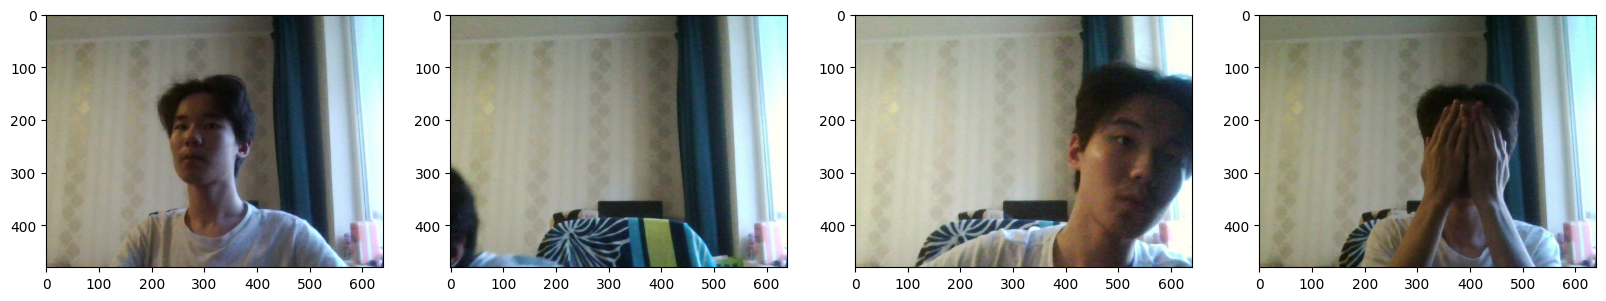

In [70]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image)
plt.show()

In [105]:
import albumentations as alb

C:\Users\xx\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [106]:
augmentor = alb.Compose([
    alb.RandomCrop(width=450, height=450),
    alb.HorizontalFlip(p=0.5),
    alb.RandomBrightnessContrast(p=0.2),
    alb.RandomGamma(p=0.2),
    alb.RGBShift(p=0.2),
    alb.VerticalFlip(p=0.5)],
    bbox_params=alb.BboxParams(format='albumentations', label_fields=['class_labels'])
)

In [99]:
img = cv2.imread(os.path.join('data','train','images','2a742245-2051-11f1-a5a0-088fc32fbdd8.jpg'))

In [100]:
with open(os.path.join('data','train','labels','2a742245-2051-11f1-a5a0-088fc32fbdd8.json'), 'r') as f:
    label = json.load(f)

In [101]:
label['shapes'][0]['points']

[[213.78378378378378, 98.37837837837837],
 [488.37837837837833, 431.35135135135135]]

In [102]:
coords = [0,0,0,0]
coords[0] = label['shapes'][0]['points'][0][0]
coords[1] = label['shapes'][0]['points'][0][1]
coords[2] = label['shapes'][0]['points'][1][0]
coords[3] = label['shapes'][0]['points'][1][1]

In [103]:
coords = np.divide(coords, [640,480,640,480]).tolist()
coords

[0.33403716216216217,
 0.20495495495495494,
 0.7630912162162161,
 0.8986486486486487]

In [115]:
augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])

In [116]:
augmented['bboxes']

[[0.10396395365397136,
  0.08366369459364154,
  0.7141741604275174,
  0.8236036067538791]]

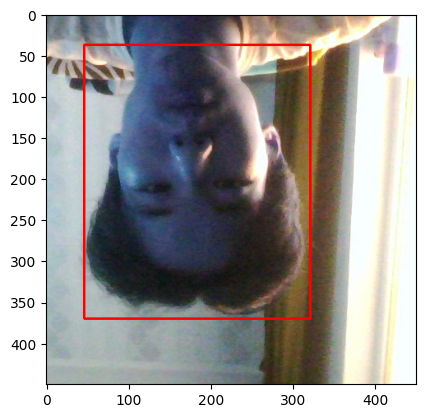

In [117]:
cv2.rectangle(augmented['image'],
              tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)),
              tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)),
              (255,0,0), 2)
plt.imshow(augmented['image'])

In [118]:
for partition in ['train', 'test', 'val']:
    image_dir = os.path.join('data', partition, 'images')
    label_dir = os.path.join('data', partition, 'labels')
    out_image_dir = os.path.join('aug_data', partition, 'images')
    out_label_dir = os.path.join('aug_data', partition, 'labels')
    os.makedirs(out_image_dir, exist_ok=True)
    os.makedirs(out_label_dir, exist_ok=True)

    for image in os.listdir(image_dir):
        image_path = os.path.join(image_dir, image)
        img = cv2.imread(image_path)
        if img is None:
            continue

        coords = [0, 0, 0.00001, 0.00001]
        stem = os.path.splitext(image)[0]
        label_path = os.path.join(label_dir, f'{stem}.json')
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                label = json.load(f)

            coords[0] = label['shapes'][0]['points'][0][0]
            coords[1] = label['shapes'][0]['points'][0][1]
            coords[2] = label['shapes'][0]['points'][1][0]
            coords[3] = label['shapes'][0]['points'][1][1]
            coords = np.divide(coords, [640, 480, 640, 480]).tolist()

        try:
            for x in range(60):
                augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                cv2.imwrite(os.path.join(out_image_dir, f'{stem}.{x}.jpg'), augmented['image'])

                annotation = {}
                annotation['image'] = image

                if os.path.exists(label_path):
                    if len(augmented['bboxes']) == 0:
                        annotation['bbox'] = [0.0, 0.0, 0.0, 0.0]
                        annotation['class'] = 0
                    else:
                        annotation['bbox'] = [float(v) for v in augmented['bboxes'][0]]
                        annotation['class'] = 1
                else:
                    annotation['bbox'] = [0.0, 0.0, 0.0, 0.0]
                    annotation['class'] = 0

                with open(os.path.join(out_label_dir, f'{stem}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)

        except Exception as e:
            print(e)

In [119]:
train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (120,120)))
train_images = train_images.map(lambda x: x/255)

In [120]:
test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (120,120)))
test_images = test_images.map(lambda x: x/255)

In [121]:
val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg', shuffle=False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (120,120)))
val_images = val_images.map(lambda x: x/255)

In [122]:
train_images.as_numpy_iterator().next()

array([[[0.62371325, 0.7716912 , 0.9542279 ],
        [0.6359069 , 0.84344363, 0.9862132 ],
        [0.5330882 , 0.7227941 , 0.9087623 ],
        ...,
        [0.24822304, 0.25686276, 0.17598039],
        [0.29013482, 0.26256126, 0.13946079],
        [0.3625613 , 0.33020833, 0.24025735]],

       [[0.53498775, 0.72518384, 0.88302696],
        [0.7120098 , 0.9120098 , 1.        ],
        [0.66979164, 0.8514706 , 0.98541665],
        ...,
        [0.3156863 , 0.27904412, 0.25104168],
        [0.3384191 , 0.2844363 , 0.2418505 ],
        [0.40508577, 0.3521446 , 0.29871324]],

       [[0.5865196 , 0.71770835, 0.9431985 ],
        [0.6778799 , 0.87101716, 0.9818627 ],
        [0.75177693, 0.9499387 , 1.        ],
        ...,
        [0.3103554 , 0.281924  , 0.25692403],
        [0.29056373, 0.26605392, 0.2194853 ],
        [0.35992646, 0.31966913, 0.266299  ]],

       ...,

       [[0.57438725, 0.6612745 , 0.70704657],
        [0.6195466 , 0.68535537, 0.7555147 ],
        [0.6231005 , 0